# End-to-End VAE-HMM Inference

#### Set the environment variable for all 11 cores

In [1]:
import os
import sys

os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=11'

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.8"

# Check if JAX has already been imported in this session
if "jax" in sys.modules:
    print("JAX already imported. Restarting kernel is necessary for XLA_FLAGS to take effect.")
    # If this prints, you MUST restart the kernel and run this cell again.

# Now import JAX (or the library that uses it, e.g. numpyro/pymc)
import jax

# Verify the devices
print(f"JAX sees {len(jax.devices())} devices:")
print(jax.devices())

JAX sees 11 devices:
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10)]


### Recommended libraries

In [2]:
import random as rnd

from scipy.interpolate import make_interp_spline

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import numpyro
from numpyro.infer import Predictive
from numpyro.diagnostics import hpdi
numpyro.set_host_device_count(4)
import jax
import optax
from jax import random
import jax.numpy as jnp
import flax.linen as nn
from scipy import stats
from tqdm import tqdm

from priorCVAE.models import MLPEncoder, MLPDecoder, VAE
from priorCVAE.priors import GP, TwoSHO
from priorCVAE.mcmc import run_mcmc_vae_hmm, vae_hmm_mcmc_inference_model
from priorCVAE.datasets import GPDataset
from priorCVAE.trainer import VAETrainer
from priorCVAE.losses import SquaredSumAndKL, MMDAndKL

from priorCVAE.viterbi import run_viterbi_decoding, robust_normalize, create_observed_mask

import jax.config as config
config.update("jax_enable_x64", True)

from flax.serialization import to_bytes, from_bytes
import os

### Configuration

Architectural Hyperparameters

In [3]:
args = {
        # architecture
        "input_dim" : 7067, # Len of the data
        "hidden_dim": 257,
        "activation_fn": nn.leaky_relu,
        "latent_dim": 64,
        
        # VAE training    
        "batch_size": 500,
        "num_iterations": 2000,
        "learning_rate": 1e-4,
        "vae_var": 1.,
        "loss": "SquaredSumAndKL",  # [SquaredSumAndKL, MMDAndKL]
    

        # MCMC inference
        "true_ls": 0.2,
        "num_warmup": 1000,
        "num_mcmc_samples": 1000,
        "num_chains": 2,
        "thinning": 1,
       }

### Generate data

We generate the data using an Two Harmonic Oscillator kernel. We plot a sample from the GP and plot the trajectories.

In [4]:
kernel = TwoSHO(log_S0_1 = 7.216781, log_w0_1 = 1.02038, log_Q_1 = 5.337618,
                 log_S0_2 = 5.836664, log_w0_2 = 1.718205, log_Q_2 = 3.186107)

gp_data_generator = GPDataset(n_data=args["input_dim"], kernel=kernel, sample_lengthscale=False, 
                              x_lim_low = 1325.942985, x_lim_high = 1335.756819) 

In [5]:
sample_x_train, sample_y_train, sample_ls_train = gp_data_generator.simulatedata(n_samples=1000)
x_test, y_test, ls_test = gp_data_generator.simulatedata(n_samples=1000) 

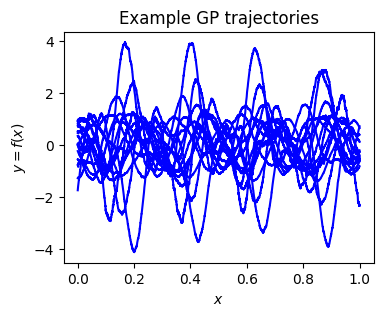

In [6]:
fig, ax = plt.subplots(figsize=(4,3))
for i in range(15):
    ax.plot(sample_x_train[i], sample_y_train[i], color='blue')
ax.set_xlabel('$x$')
ax.set_ylabel('$y=f(x)$')
ax.set_title('Example GP trajectories')

plt.show()

### PriorCVAE Model

We define the PriorCVAE model, optimizer, and initialize the parameters of the model randomly.

In [7]:
out_dim = args["input_dim"]
hidden_dim = args["hidden_dim"]
activation_fn = args["activation_fn"]
latent_dim = args["latent_dim"]
batch_size = args["batch_size"]
num_iterations  = args["num_iterations"]
true_ls = args["true_ls"]
learning_rate = args["learning_rate"]
vae_var = args["vae_var"]
loss = args["loss"]

In [8]:
encoder = MLPEncoder(hidden_dim, latent_dim, activation_fn)
decoder = MLPDecoder(hidden_dim, out_dim, activation_fn)
model = VAE(encoder, decoder)

optimizer = optax.adam(learning_rate=learning_rate)

if loss == "MMDAndKL":
    kernel = SquaredExponential(5.0, 1.0)
    loss = MMDAndKL(kernel, conditional=conditional)
else:
    loss = SquaredSumAndKL(vae_var=vae_var)

### Train the model

Train the model and plot the train loss and the test loss.

In [ ]:
trainer = VAETrainer(model, optimizer, loss=loss)
trainer.init_params(sample_y_train[0])

test_set = (x_test, y_test, ls_test)
loss_vals, test_vals, time_taken = trainer.train(gp_data_generator, test_set, num_iterations)

print(f'Training of {num_iterations} iterations took {round(time_taken)} seconds')

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].plot(range(len(loss_vals)), loss_vals)
axs[0].set_title('Training loss')

axs[1].plot(range(len(test_vals)), test_vals)
axs[1].set_title("Test loss")


## Save and Load the Decoder

OPTIONAL: We recommend this configuration for any subsequent MCMC inference utilizing the same decoder architecture.

In [ ]:
decoder_params = trainer.state.params['decoder']

save_path = "checkpoints/decoder_params_tess2018206045859-s0001-0000000089257479-0120-s_lc_part_1_2_3_VAE.msgpack"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "wb") as f:
    f.write(to_bytes(decoder_params))

In [9]:
# Dummy init for structure (same shape and dtype as during training)
dummy_z = jnp.ones((1, latent_dim))

# Recreate the decoder object (same config as before)
decoder = MLPDecoder(hidden_dim, out_dim, activation_fn)
init_params = decoder.init(jax.random.PRNGKey(0), dummy_z)

# Now load the saved parameters
with open("checkpoints/decoder_params_tess2018206045859-s0001-0000000089257479-0120-s_lc_part_1_2_3_VAE.msgpack", "rb") as f:
    decoder_params = from_bytes(init_params["params"], f.read())

### Trained Decoder

We plot a sample of trajectories from the trained decoder model.

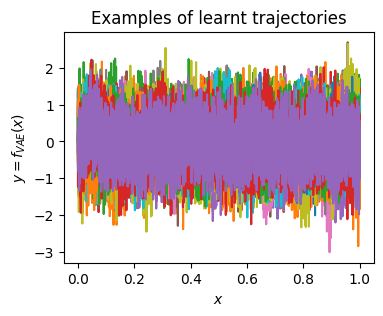

In [10]:
#decoder_params = trainer.state.params['decoder']
key = jax.random.PRNGKey(rnd.randint(0, 9999))
rng, z_rng, init_rng = random.split(key, 3)
z = random.normal(z_rng, (batch_size, latent_dim))

decoder = MLPDecoder(hidden_dim, out_dim, activation_fn)

out = decoder.apply({'params': decoder_params}, z)             

fig, ax = plt.subplots(figsize=(4,3))
for i in range(15):
    ax.plot(sample_x_train[0], out[i,:])
ax.set_xlabel('$x$')
ax.set_ylabel('$y=f_{VAE}(x)$')
ax.set_title('Examples of learnt trajectories')

plt.show()

## Empirical Data

Normalizing observations acquired from the TESS and Kepler missions.

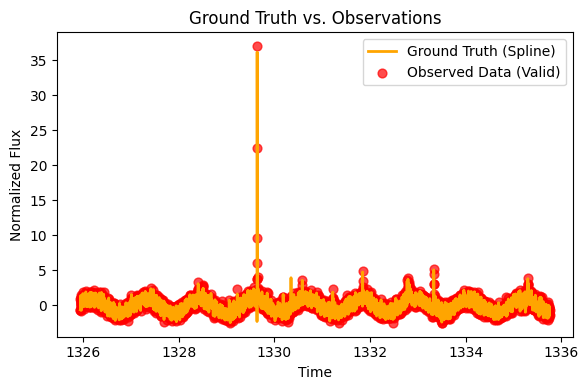

In [11]:
# Loading the data
time, trend = np.genfromtxt('data/Stellar_Flares/tess2018206045859-s0001-0000000089257479-0120-s_lc/1_2_3.csv', 
                            delimiter=',', 
                            skip_header=1, 
                            usecols=(0, 7),  
                            missing_values='NA', 
                            filling_values=np.nan, 
                            unpack=True)

# Normalize the trend (NaNs are preserved)
trend_norm = robust_normalize(trend)

# Create Mask (identifies where NaNs are)
observed_mask = create_observed_mask(trend_norm)
y_filled = np.nan_to_num(trend_norm, nan=0.0)

# Create a "Valid Data" mask
# We use this to filter out NaNs from both Time and Trend arrays
valid_idx = ~np.isnan(trend_norm)

# Filter the arrays: keep only the rows where data exists
t_valid = time[valid_idx]
y_valid = trend_norm[valid_idx]

# Smoothing (Spline Interpolation)
# ONLY use valid data to build the spline
# (If we included NaNs here, the spline math would break)
spline_model = make_interp_spline(t_valid, y_valid, k=3)

# Create a smooth X-axis for the line plot
time_smooth = np.linspace(t_valid.min(), t_valid.max(), len(y_valid))
trend_smooth = spline_model(time_smooth)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(time_smooth, trend_smooth, color='orange', linewidth=2, label='Ground Truth (Spline)')
plt.scatter(t_valid, y_valid, color='red', s=40, alpha=0.7, label='Observed Data (Valid)')
plt.title('Ground Truth vs. Observations')
plt.xlabel('Time')
plt.ylabel('Normalized Flux')
plt.tight_layout()
plt.legend()
plt.show()

## Joint MCMC Inference

In [12]:
# Add data to args. 
 # --- Data ---
args["y_full"] = y_filled
args["observed_mask"] = observed_mask

# --- HMM priors (same as Stan) ---
args["alpha_quiet"] = jnp.array([1.0, 0.1])
args["alpha_firing"] = jnp.array([1.0, 1.0])
args["alpha_decay"] = jnp.array([1.0, 0.1, 1.0])
args["lambda_quiet"] = 0.01
args["gamma_noise"] = jnp.array([0.01, 0.01])
args["mu0_rate_firing"] = 0.0
args["sigma_rate_firing"] = 1 ## Before = 0.001
args["mu0_rate_decay"] = 0.0
args["sigma_rate_decay"] = 1 ## Before = 0.001

In [13]:
rng_key_draw =  random.PRNGKey(1)
rng_key, rng_key_post, rng_key_preds, rng_key_draw = random.split(rng_key_draw, 4)

mcmc_vae, mcmc_vae_samples, t_elapsed = run_mcmc_vae_hmm(
    rng_key_post, vae_hmm_mcmc_inference_model, args, decoder, decoder_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
  logitrate_decay      0.21      0.05      0.21      0.14      0.29   2040.26      1.00
   lograte_firing     -0.10      0.13     -0.09     -0.28      0.14   2104.54      1.00
       rate_decay      0.55      0.01      0.55      0.53      0.57   2040.95      1.00
      rate_firing      0.92      0.12      0.91      0.73      1.12   2206.17      1.00
      sigma_noise      0.52      0.00      0.52      0.52      0.53   2143.21      1.00
   theta_decay[0]      0.10      0.02      0.10      0.06      0.14   2301.48      1.00
   theta_decay[1]      0.30      0.07      0.30      0.18      0.41   2020.04      1.00
   theta_decay[2]      0.60      0.08      0.60      0.48      0.72   2108.34      1.00
  theta_firing[0]      0.12      0.05      0.12      0.03      0.20   2132.04      1.00
  theta_firing[1]      0.88      0.05      0.88      0.80      0.97   2132.04      1.00
   theta_quiet[0]      1.00    

## Final Results

1.- VAE-predicted Celerite trend overlaid on the normalized data

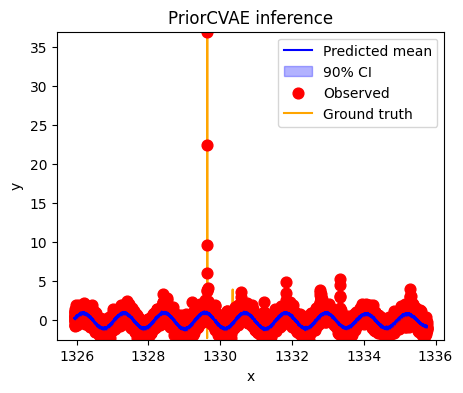

In [14]:
predictive = Predictive(vae_hmm_mcmc_inference_model, mcmc_vae_samples)


predictions_vae = predictive(rng_key_preds, args, decoder, decoder_params)["trend"]

# Compute statistics in real units
mean_post_pred_vae = jnp.mean(predictions_vae, axis=0)
percentiles_vae = np.percentile(predictions_vae, [5.0, 95.0], axis=0)

time_smooth = np.linspace(time.min(), time.max(), len(y_valid))
trend_smooth = spline_model(time_smooth)

time_smooth = np.asarray(time_smooth)
mean_post_pred_vae = np.asarray(mean_post_pred_vae)
percentiles_vae = np.asarray(percentiles_vae)


# PriorCVAE prediction 
plt.figure(figsize=(5, 4))
plt.plot(time, mean_post_pred_vae, label="Predicted mean", color="blue", zorder=3)
plt.fill_between(
    time, 
    percentiles_vae[0, :], 
    percentiles_vae[1, :], 
    alpha=0.3, 
    interpolate=True,
    color="blue", 
    label="90% CI",
    zorder=2
)

# Real observed data
plt.scatter(t_valid, y_valid, color="red", label="Observed", s=60, zorder=1)
plt.plot(time_smooth, trend_smooth, label="Ground truth", color="orange", zorder=0)

plt.title('PriorCVAE inference')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Set y-limits to include all curves
all_y = np.concatenate([y_filled, mean_post_pred_vae, percentiles_vae[0], percentiles_vae[1]])
plt.ylim([all_y.min(), all_y.max()])

plt.show()


2.- Comprehensive VAE-HMM output: Showing the reconstructed trend alongside discrete state classifications for each observation.

Generating trend samples...
Running Viterbi Algorithm...
Plotting results...


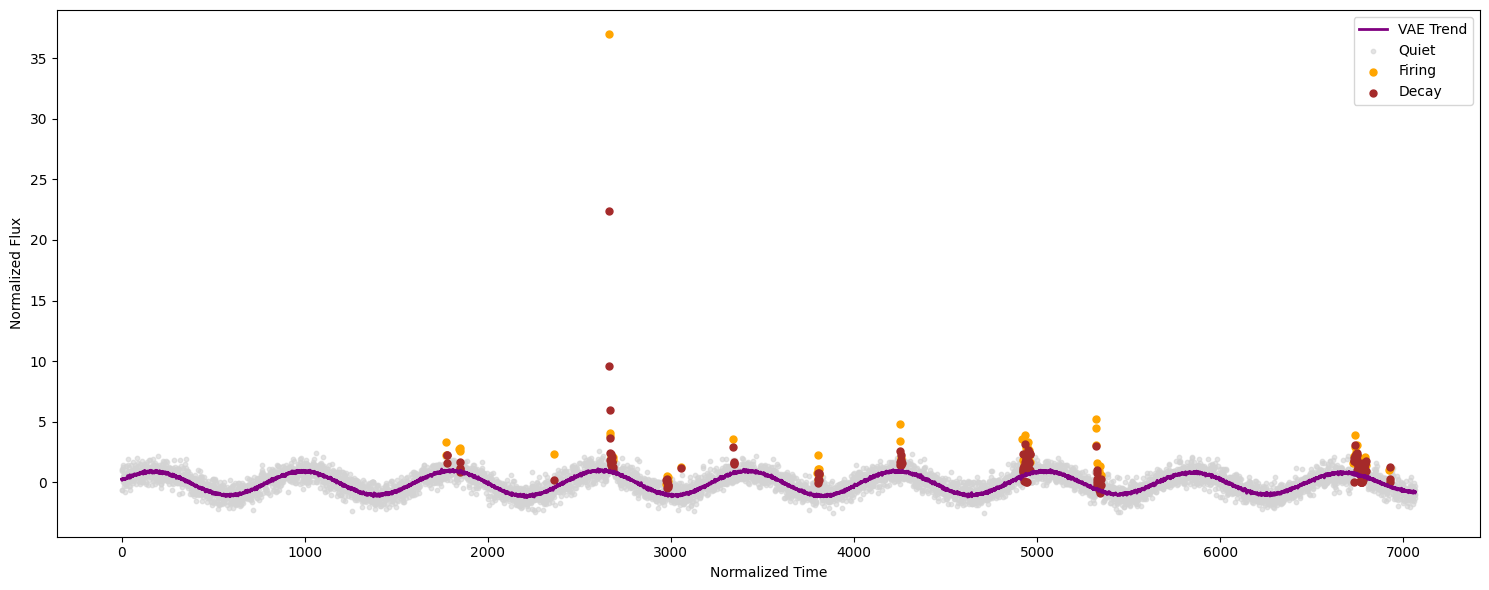

In [15]:
# --- 1. Generate the Trend using Predictive ---
# This handles z + c shapes automatically.
predictive = Predictive(vae_hmm_mcmc_inference_model, mcmc_vae_samples)

# Run prediction
print("Generating trend samples...")
predictions = predictive(rng_key_preds, args, decoder, decoder_params)
predictions_vae = predictions["trend"]

# Calculate the "Best Trend" (Posterior Mean)
best_trend = jnp.mean(predictions_vae, axis=0)

# --- 2. Extract HMM Parameters (Posterior Means) ---
# We take the average of the MCMC samples for the Viterbi logic
mean_params = {
    'sigma_noise': jnp.mean(mcmc_vae_samples['sigma_noise']),
    
    # Handle rates (Transform if they were sampled as log/logit)
    'rate_firing': jnp.mean(mcmc_vae_samples.get('rate_firing', jnp.exp(mcmc_vae_samples.get('lograte_firing', 0.0)))),
    
    # Sigmoid transform for decay if needed: x / (1 + |x|) or standard sigmoid
    'rate_decay': jnp.mean(mcmc_vae_samples.get('rate_decay', 
                  1.0 / (1.0 + jnp.exp(-mcmc_vae_samples.get('logitrate_decay', 0.0)))
                  )),
                  
    'theta_quiet': jnp.mean(mcmc_vae_samples['theta_quiet'], axis=0),
    'theta_firing': jnp.mean(mcmc_vae_samples['theta_firing'], axis=0),
    'theta_decay': jnp.mean(mcmc_vae_samples['theta_decay'], axis=0)
}

# --- 3. Run Viterbi Classification ---
print("Running Viterbi Algorithm...")
# Note: Ensure args["y_full"] contains the same normalized data used for fitting
states = run_viterbi_decoding(
    y=args["y_full"], 
    trend=best_trend, 
    observed_mask=args.get("observed_mask", jnp.ones_like(best_trend)), 
    params=mean_params
)

# --- 4. Plot the Result ---
print("Plotting results...")
plt.figure(figsize=(15, 6))

time_axis = np.arange(len(best_trend)) # Or your time array

# Plot VAE Trend
plt.plot(time_axis, best_trend, color='purple', lw=2, label='VAE Trend', zorder=10)

# Plot Points Colored by State
y_data = args["y_full"]

# State 1: Quiet (Grey)
mask_q = (states == 1)
plt.scatter(time_axis[mask_q], y_data[mask_q], c='lightgrey', s=10, alpha=0.6, label='Quiet')

# State 2: Firing (Orange)
mask_f = (states == 2)
plt.scatter(time_axis[mask_f], y_data[mask_f], c='orange', s=25, label='Firing', zorder=5)

# State 3: Decay (Brown)
mask_d = (states == 3)
plt.scatter(time_axis[mask_d], y_data[mask_d], c='brown', s=25, label='Decay', zorder=5)

#plt.title("Final Result: VAE Trend + HMM Detection")
plt.xlabel("Normalized Time")
plt.ylabel("Normalized Flux")
plt.legend()
plt.tight_layout()
#plt.savefig('figures/VAE+HMM/full_model/tess2018206045859-s0001-0000000089257479-0120-s_lc_files_1_2_3.pdf', bbox_inches='tight')
plt.show()